# Defining the region

We define our **region of interest**:

| Corner | Longitude | Latitude |
| --- | --- | --- |
| Northwest (NW) | 86.582°E | 28.041°N |
| Northeast (NE) | 86.989°E | 28.041°N |
| Southwest (SW) | 86.582°E | 27.770°N |
| Southeast (SE) | 86.989°E | 27.770°N |

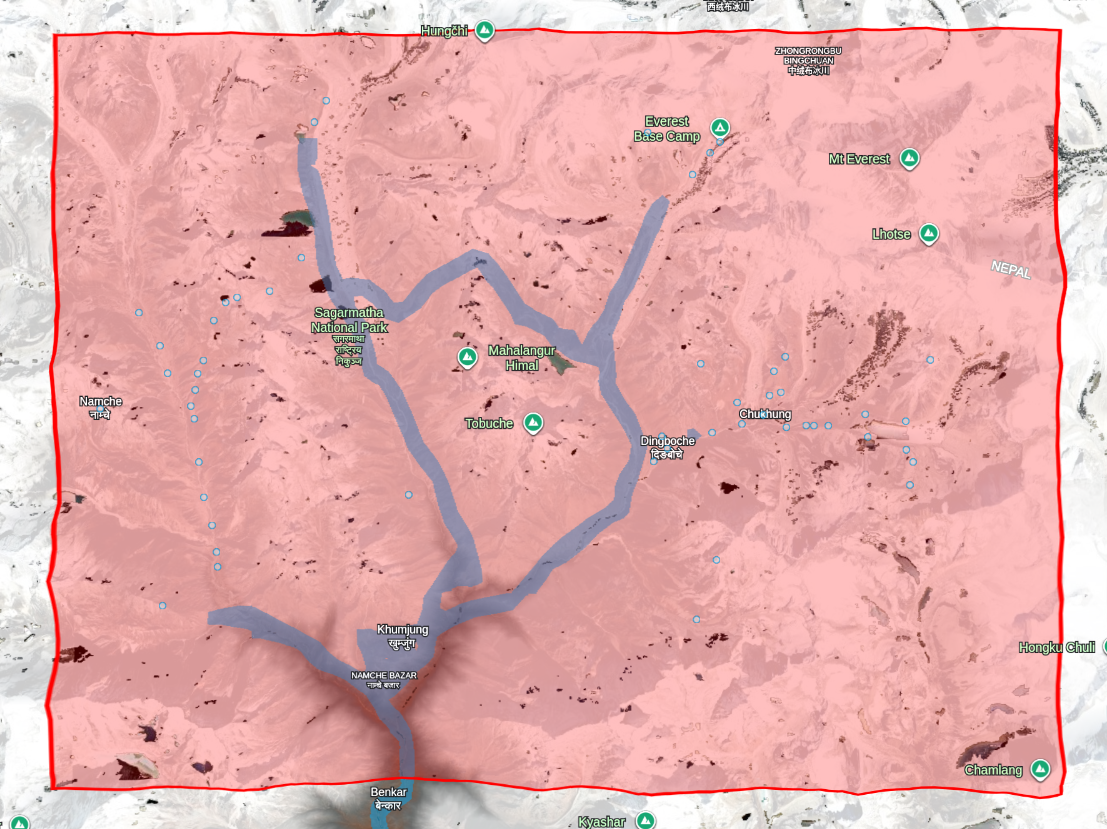

In [1]:
min_lon = 86.582 #degrees  (South)
max_lon = 86.989 #degrees  (North)
min_lat = 27.770 #degrees  (West)
max_lat = 28.041 #degrees  (East)

In [2]:
buffer_download  = 85_000 #meters
buffer_crop      = 80_000 #meters

We need to add the 80km buffer zones to each side of the **RoI**.

But since our region is defined in longitude/latitude (degrees).<br/>
We need a method to convert meters to degrees and degrees to meters.

For correct conversion, we need to choose the correct UTM zone for Khumbu which is 45N.

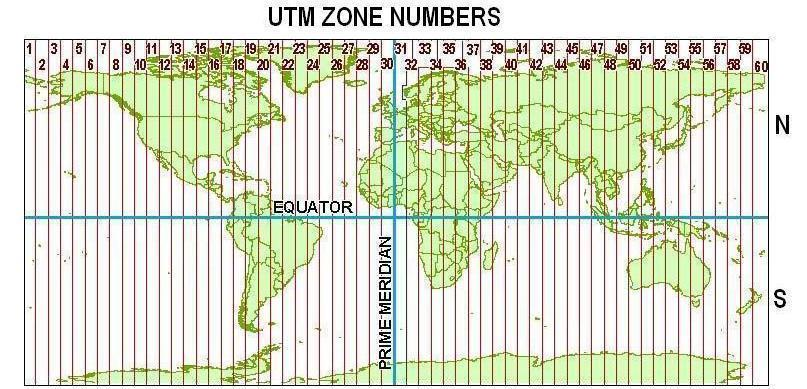

# Converting between coordinate systems

In [3]:
from pyproj import Transformer
from pyproj.transformer import AreaOfInterest

In [4]:
# GPS longitude/latitude degrees (EPSG:4326)
# UTM Zone 45N meters (EPSG:32645) - The correct projected zone for eastern Nepal

khumbu_aoi = AreaOfInterest(
    west_lon_degree=min_lon,
    south_lat_degree=min_lat,
    east_lon_degree=max_lon,
    north_lat_degree=max_lat
)

gps_to_utm = Transformer.from_crs(
    "EPSG:4326", 
    "EPSG:32645", 
    always_xy=True, 
    area_of_interest=khumbu_aoi
)

utm_to_gps = Transformer.from_crs(
    "EPSG:32645", 
    "EPSG:4326", 
    always_xy=True, 
    area_of_interest=khumbu_aoi
)

In [5]:
min_x, min_y = gps_to_utm.transform(min_lon, min_lat) #meters
max_x, max_y = gps_to_utm.transform(max_lon, max_lat) #meters

print(f"MIN (X, Y): ({min_x/1000:.2f}km, {min_y/1000:.2f}km)   # South-West")
print(f"MAX (X, Y): ({max_x/1000:.2f}km, {max_y/1000:.2f}km)   # North-East")
print()
print(f"The area is {(max_x-min_x)/1000:.2f}km x {(max_y-min_y)/1000:.2f}km")

MIN (X, Y): (458.81km, 3071.79km)   # South-West
MAX (X, Y): (498.92km, 3101.74km)   # North-East

The area is 40.10km x 29.95km


<hr/>

# Adding buffer to region

In [6]:
buffered_min_x = min_x - buffer_download
buffered_max_x = max_x + buffer_download
buffered_min_y = min_y - buffer_download
buffered_max_y = max_y + buffer_download

print("The area after adding the buffers to each side:")
print(f"MIN (X, Y): ({buffered_min_x/1000:.2f}km, {buffered_min_y/1000:.2f}km)   # South-West")
print(f"MAX (X, Y): ({buffered_max_x/1000:.2f}km, {buffered_max_y/1000:.2f}km)   # North-East")
print()
print(f"The new area is {(buffered_max_x-buffered_min_x)/1000:.2f}km x {(buffered_max_y-buffered_min_y)/1000:.2f}km")

The area after adding the buffers to each side:
MIN (X, Y): (373.81km, 2986.79km)   # South-West
MAX (X, Y): (583.92km, 3186.74km)   # North-East

The new area is 210.10km x 199.95km


Now, we have the region with buffers added in (x,y) format.<br/>
But, for downloading, we require the longitude/latitude.

In [7]:
buffered_min_lon, buffered_min_lat = utm_to_gps.transform(buffered_min_x, buffered_min_y) #degrees
buffered_max_lon, buffered_max_lat = utm_to_gps.transform(buffered_max_x, buffered_max_y) #degrees

print(f"MIN (Latitude, Longitude): {buffered_min_lat:.4f}°N, {buffered_min_lon:.4f}°E   # South-West")
print(f"MAX (Latitude, Longitude): {buffered_max_lat:.4f}°N, {buffered_max_lon:.4f}°E   # North-East")

MIN (Latitude, Longitude): 26.9975°N, 85.7282°E   # South-West
MAX (Latitude, Longitude): 28.8055°N, 87.8600°E   # North-East


<hr/>

# Downloading DEM tiles

In [8]:
from dem_stitcher import stitch_dem

In [10]:
bounds = [buffered_min_lon, buffered_min_lat, buffered_max_lon, buffered_max_lat]
elevation_data, profile = stitch_dem(
    bounds,                        # Area to download
    dem_name='glo_30',             # Copernicus GLO-30
    dst_ellipsoidal_height=False   # Heights are relative to sea level, not WGS84 ellipsoid.
)

Reading tile imagery: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [02:32<00:00, 16.99s/it]


In [11]:
elevation_data

array([[4836.528  , 4836.1196 , 4834.7017 , ..., 4457.3965 , 4458.016  ,
        4458.5244 ],
       [4831.7437 , 4831.355  , 4829.945  , ..., 4457.9077 , 4458.299  ,
        4458.768  ],
       [4827.2695 , 4826.636  , 4825.3267 , ..., 4457.3657 , 4457.5176 ,
        4458.3086 ],
       ...,
       [ 162.2749 ,  162.23468,  162.04398, ..., 2097.9749 , 2082.6802 ,
        2065.9397 ],
       [ 161.9889 ,  162.28955,  161.77885, ..., 2094.465  , 2078.9302 ,
        2066.9636 ],
       [ 161.51794,  161.61176,  162.18538, ..., 2096.4214 , 2079.6387 ,
        2065.5825 ]], shape=(6510, 7675), dtype=float32)

In [12]:
profile

{'driver': 'GTiff', 'dtype': <class 'numpy.float32'>, 'nodata': nan, 'width': 7675, 'height': 6510, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0002777777777777778, 0.0, 85.72833333333334,
       0.0, -0.0002777777777777778, 28.805555555555557), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}

<hr/>

# Saving the stitched tiles

Now, we can save the elevation data and the metadata into a GeoTIFF file.

In [13]:
import os
os.makedirs("data", exist_ok=True)  # Create data folder if doesn't exist already

For raycasting, we'd need to calculate slopes and distances which is only possible in (x,y) i.e. UTM.<br/>
Currently, our data is in `WGS84` i.e. latitude/longitude. We also crop the buffer to be 80km not 85km.
It was increased while downloading so, missing values can be prevented.

Source: `EPSG:4326`
Destination: `EPSG:32645`

In [14]:
crop_min_x = min_x - buffer_crop
crop_max_x = max_x + buffer_crop
crop_min_y = min_y - buffer_crop
crop_max_y = max_y + buffer_crop

crop_width = int(round((crop_max_x - crop_min_x) / 30.0))
crop_height = int(round((crop_max_y - crop_min_y) / 30.0))

In [3]:
import rasterio
from rasterio.warp import reproject, Resampling

In [16]:
crop_transform = rasterio.transform.from_origin(crop_min_x, crop_max_y, 30.0, 30.0)
crop_meta = {
    'driver': 'GTiff',
    'height': crop_height,
    'width': crop_width,
    'count': 1,
    'dtype': 'float32',
    'crs': "EPSG:32645",
    'transform': crop_transform
}

In [1]:
dem_file = "data/digital_elevation_model/dem.tif"

In [18]:
with rasterio.open(dem_file, 'w', **crop_meta) as dst:
    reproject(
        source=elevation_data,
        destination=rasterio.band(dst, 1),
        src_transform=profile['transform'],
        src_crs=profile['crs'],
        dst_transform=crop_transform,
        dst_crs="EPSG:32645",
        resampling=Resampling.bilinear
    )

<hr/>

# Plotting the DEM
We can plot the elevation and shade relief map after the correct projections.

In [ ]:
with rasterio.open(dem_file) as src:
    dem_data = src.read(1)
    
    extent = [
        src.bounds.left / 1000.0,
        src.bounds.right / 1000.0,
        src.bounds.bottom / 1000.0,
        src.bounds.top / 1000.0
    ]
    
    # Read the Coordinate Reference System (to label the axes properly)
    crs_name = src.crs.to_string()

In [5]:
import matplotlib.pyplot as plt

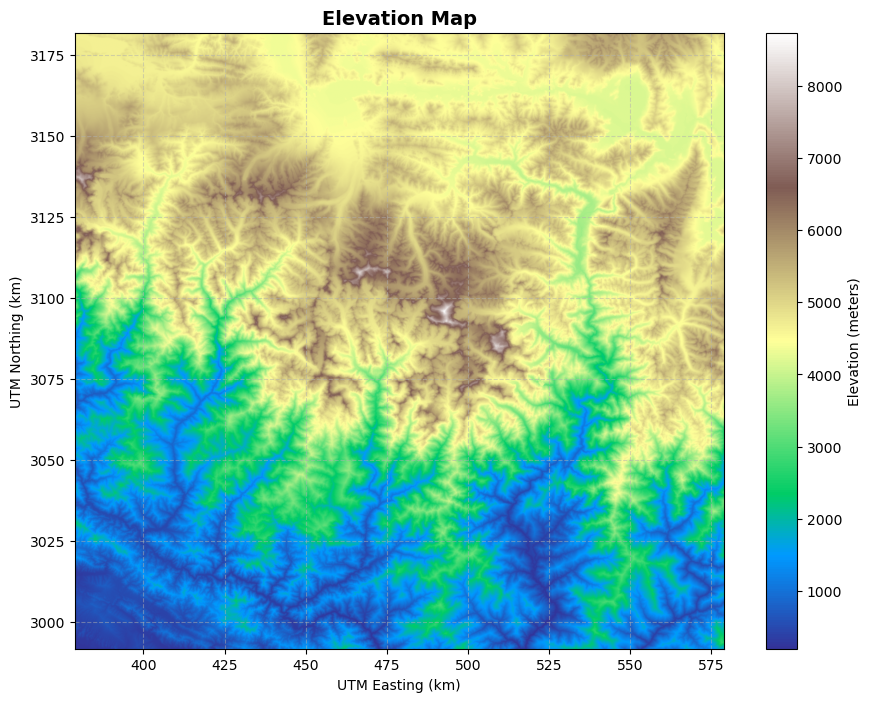

In [6]:
plt.figure(figsize=(11, 8))

# We use the 'terrain' colormap which is standard for geographic relief maps
img = plt.imshow(dem_data, cmap='terrain', extent=extent)

# Add a colorbar to show elevation values
plt.colorbar(img, label="Elevation (meters)")

# Add titles and labels
plt.title("Elevation Map", fontsize=14, fontweight='bold')
if "32645" in crs_name:
    plt.xlabel("UTM Easting (km)")
    plt.ylabel("UTM Northing (km)")
else:
    plt.xlabel("Longitude (degrees)")
    plt.ylabel("Latitude (degrees)")

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [7]:
from matplotlib.colors import LightSource

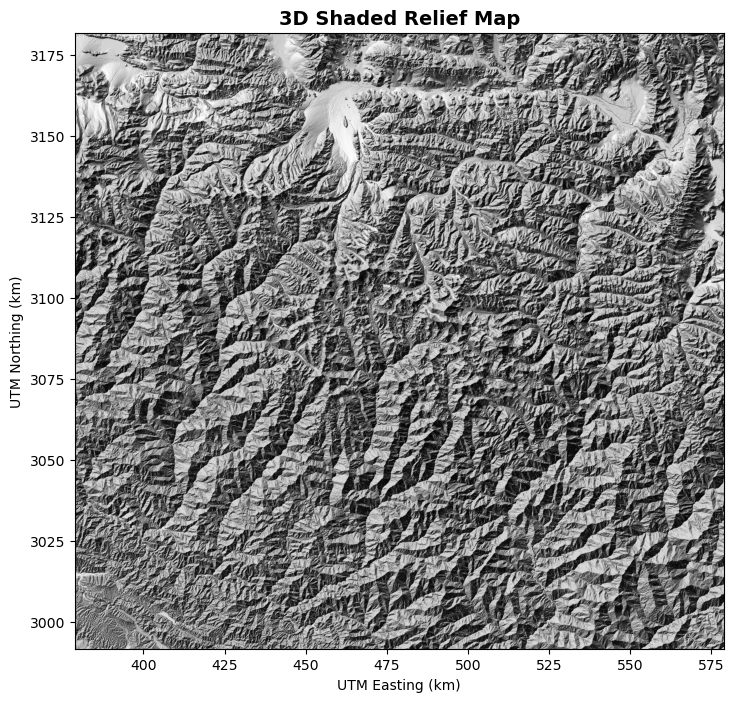

In [8]:
# Configure a virtual light source (simulating sun lighting)
# azdeg=315: Sun is shining from the Northwest
# altdeg=45: Sun is at a 45-degree angle in the sky
ls = LightSource(azdeg=315, altdeg=45)

# Compute the shaded relief map
# 'fraction=0.5' controls how deep/dark the shadows are
shaded_terrain = ls.hillshade(dem_data, fraction=0.5)

plt.figure(figsize=(11, 8))

# We use a grayscale 'gray' colormap for the hillshade to show raw 3D structure
plt.imshow(shaded_terrain, cmap='gray', extent=extent)

plt.title("3D Shaded Relief Map", fontsize=14, fontweight='bold')
if "32645" in crs_name:
    plt.xlabel("UTM Easting (km)")
    plt.ylabel("UTM Northing (km)")
else:
    plt.xlabel("Longitude (degrees)")
    plt.ylabel("Latitude (degrees)")

plt.show()

In [9]:
import numpy as np

In [10]:
min_elev = np.nanmin(dem_data)
max_elev = np.nanmax(dem_data)
nan_count = np.isnan(dem_data).sum()
total_pixels = dem_data.size

print(f"Minimum Elevation: {min_elev:.1f} meters")
print(f"Maximum Elevation: {max_elev:.1f} meters")
print(f"Percentage of missing data (NaN): {(mask_nan := nan_count / total_pixels) * 100:.2f}%")

Minimum Elevation: 199.5 meters
Maximum Elevation: 8735.7 meters
Percentage of missing data (NaN): 0.00%


No missing data. The max elevation (8848.86) has been smoothed to 8737.3 due to 30m resolution.